In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
from movement_samplers import RandomCommuterSampler, PerfectCommuterSampler
from epidemic import Epidemic
from grab_data import get_matrix, get_population_sizes
from simple_model import fit_model, visualise_fits
from itertools import product
import numpy as np
import matplotlib.pyplot as plt

# Run epidemic on mock data
Get everything working using mock data, then can always switch over to commuter data when going to bed to leave on overnight.

In [55]:
DATASET = 'MOCK'
od_matrix = get_matrix(DATASET)
pop_sizes = get_population_sizes(DATASET)

# Run a perfect epidemic

In [56]:
perfect_epi = Epidemic(movement_sampler=PerfectCommuterSampler, od_matrix=od_matrix, population_sizes=pop_sizes)
perfect_sim = perfect_epi.simulate()
fit_model(perfect_sim, od_matrix, pop_sizes)

Simulation finished, aggregating states.


(1.4588785135775997, 0.24875269469107011, 0.875788936387767)

In [36]:
random_epi = Epidemic(movement_sampler=RandomCommuterSampler, od_matrix=od_matrix, population_sizes=population_sizes)
random_s, random_i, random_r = random_epi.simulate()

Simulation finished, aggregating states.


In [57]:
def simulate_and_fit(flow_matrix, population_sizes, seed_patch=0, movement='PERFECT', t_max=100, t_delta=1):
    if movement == 'PERFECT':
        sampler = PerfectCommuterSampler
    if movement == 'RANDOM':
        sampler = RandomCommuterSampler

    true_params = list(product(np.linspace(1, 3, 5), np.linspace(0.2, 0.8, 5), np.array([0.9, 0.8, 0.7])))
    results = [[], [], []]
    for b, g, p in true_params:
        if b / g <= 1:
            continue
        # TODO implement custom time-steps in Epidemic
        epidemic = Epidemic(beta=b, gamma=g, psi=p,movement_sampler=RandomCommuterSampler, od_matrix=flow_matrix,
                            population_sizes=population_sizes, seed_patch=seed_patch, t_max=t_max)
        sim_data = epidemic.simulate()
        # not interested in extinctions
        while sim_data[1].sum(axis=(0, 1)) <= 100:
            epidemic = Epidemic(beta=b, gamma=g, psi=p,movement_sampler=RandomCommuterSampler, od_matrix=flow_matrix,
                                population_sizes=population_sizes, seed_patch=seed_patch, t_max=t_max)
            sim_data = epidemic.simulate()
        b_hat, g_hat, psi_hat = fit_model(sim_data, flow_matrix, population_sizes, t_delta=t_delta)
        results[0].append(b_hat)
        results[1].append(g_hat)
        results[2].append(psi_hat)

    return np.array(true_params), np.array(results).T

In [74]:
%%capture
perfect_fits = simulate_and_fit(od_matrix, pop_sizes, movement='PERFECT')

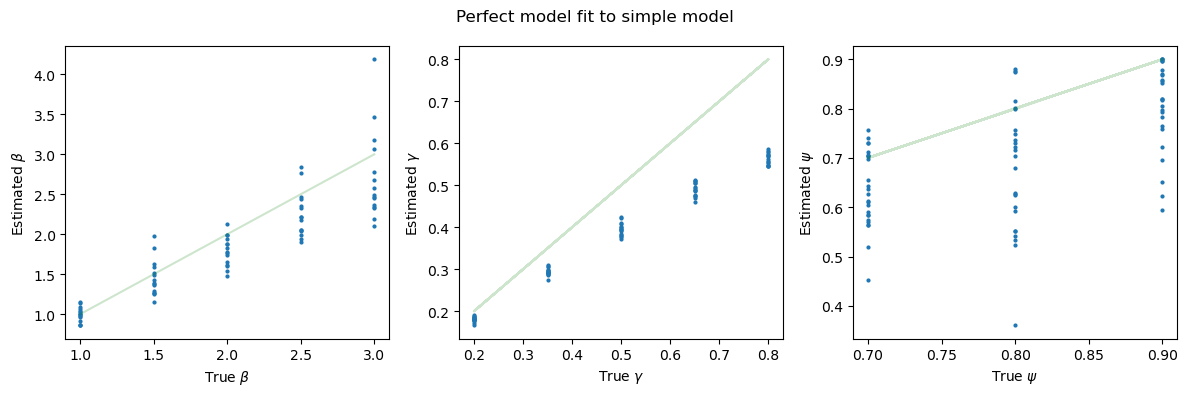

In [75]:
visualise_fits(*perfect_fits, title='Perfect model fit to simple model')

In [69]:
%%capture
random_fits = simulate_and_fit(od_matrix, pop_sizes, movement='RANDOM')

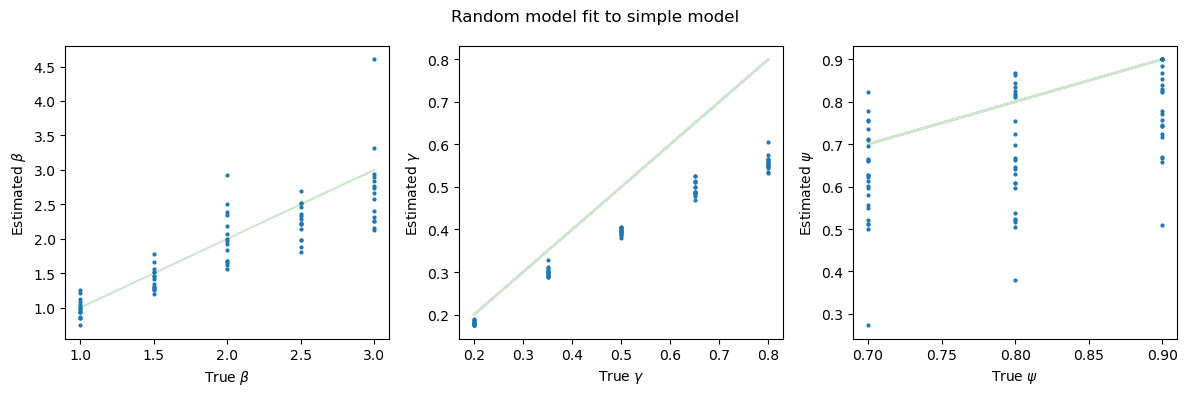

In [76]:
visualise_fits(*random_fits, title='Random model fit to simple model')